<div style="padding:12px 16px; border-left:6px solid #1f4ed8; background:#eef2ff;">
  <h2 style="margin:0; color:#1f4ed8; font-weight:800;">Project 2</h2>
  <p style="margin:4px 0 0 0; font-size:16px; color:#0f172a;">
    Prepared by <strong>Ayush Mishra</strong> (<span style="color:#1f4ed8; font-weight:600;">Unified Mentor Intern</span>)
  </p>
</div>

# Netflix Data Cleaning and EDA

### Environment Setup

Purpose:
- Import core Python libraries for data wrangling, visualization, and text rendering.
- Set a consistent visual theme for all charts.

How it executes:
- Python resolves installed packages from your active environment.
- If a package is missing (e.g., `wordcloud`), install it with `pip install wordcloud` and re-run.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
sns.set_theme(style="whitegrid")

### Load Dataset and Preview

Purpose:
- Read the CSV into a DataFrame and quickly inspect schema and a sample of rows.

How it executes:
- `pd.read_csv` parses `netflix1.csv` using the header row to set column names.
- `display(head)` renders the first five rows; printed columns confirm field availability.

In [ ]:
path = "netflix1.csv"
data = pd.read_csv(path)
display(data.head())
print(list(data.columns))

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


['show_id', 'type', 'title', 'director', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in']


### Assess Missing Data

Purpose:
- Quantify nulls per column to understand data completeness before cleaning.

How it executes:
- `isnull().sum()` computes null counts across columns and displays them for quick review.

In [ ]:
missing = data.isnull().sum()
display(missing)

show_id         0
type            0
title           0
director        0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
dtype: int64

### Clean and Augment Data

Purpose:
- Remove duplicates, drop rows missing critical fields, normalize types, and engineer helper columns.
- Prepare `genres`, `year_added`, and `month_added` for downstream analysis and charts.

How it executes:
- Deduplication uses `drop_duplicates`.
- Critical null handling enforces presence of `director` and `country` where available.
- `to_datetime` parses `date_added`; numeric conversion ensures `release_year` type.
- `listed_in` is split into a list for aggregation.

In [ ]:
data.drop_duplicates(inplace=True)
critical = [c for c in ["director", "country"] if c in data.columns]
if critical:
    data.dropna(subset=critical, inplace=True)
if "date_added" in data.columns:
    data["date_added"] = pd.to_datetime(data["date_added"], errors="coerce")
if "release_year" in data.columns:
    data["release_year"] = pd.to_numeric(data["release_year"], errors="coerce").astype('Int64')
if "listed_in" in data.columns:
    data["genres"] = data["listed_in"].fillna("").apply(lambda x: [s.strip() for s in str(x).split(",") if s.strip()])
if "date_added" in data.columns:
    data["year_added"] = data["date_added"].dt.year
    data["month_added"] = data["date_added"].dt.month
display(data.head())

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in,genres,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries,[Documentaries],2021,9
1,s3,TV Show,Ganglands,Julien Leclercq,France,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...","[Crime TV Shows, International TV Shows, TV Ac...",2021,9
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries","[TV Dramas, TV Horror, TV Mysteries]",2021,9
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,2021-09-22,2021,TV-PG,91 min,"Children & Family Movies, Comedies","[Children & Family Movies, Comedies]",2021,9
4,s8,Movie,Sankofa,Haile Gerima,United States,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","[Dramas, Independent Movies, International Mov...",2021,9


## Content Type Distribution

Purpose:
- Compare counts of Movies vs TV Shows to understand catalog composition.

How it executes:
- `value_counts()` aggregates by the `type` column and a bar plot renders the distribution.

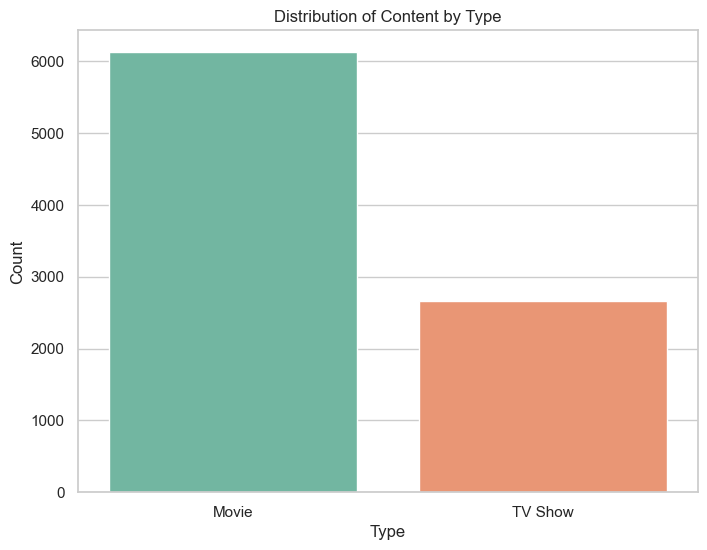

In [ ]:
if "type" in data.columns:
    counts = data["type"].value_counts()
    plt.figure(figsize=(8,6))
    sns.barplot(x=counts.index, y=counts.values, palette="Set2")
    plt.title("Distribution of Content by Type")
    plt.xlabel("Type")
    plt.ylabel("Count")
    plt.show()

## Most Common Genres

Purpose:
- Identify the top genres by exploding the comma-separated `listed_in` field.

How it executes:
- Each row's `listed_in` is split into a list; all lists are concatenated and counted.
- The top 10 counts are visualized as a horizontal bar chart.

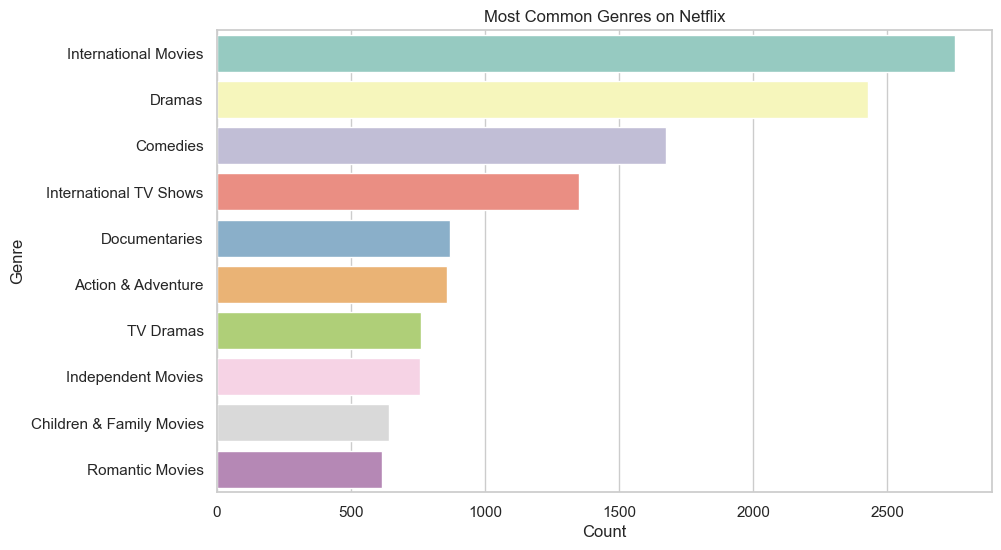

In [ ]:
if "genres" in data.columns:
    all_genres = sum(data["genres"], []) if len(data) else []
    counts = pd.Series(all_genres).value_counts().head(10)
    plt.figure(figsize=(10,6))
    sns.barplot(x=counts.values, y=counts.index, palette="Set3")
    plt.title("Most Common Genres on Netflix")
    plt.xlabel("Count")
    plt.ylabel("Genre")
    plt.show()

## Content Added Over Time

Purpose:
- Reveal acquisition/ingestion trends by year to spot growth patterns.

How it executes:
- Uses `year_added` derived from `date_added` and counts rows per year with a bar chart.

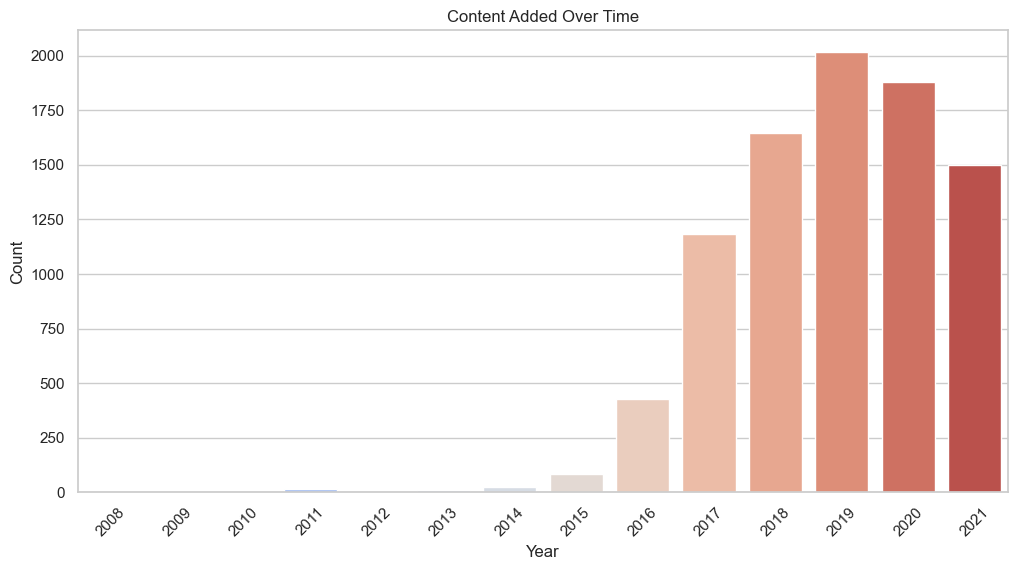

In [ ]:
if "year_added" in data.columns:
    plt.figure(figsize=(12,6))
    sns.countplot(x="year_added", data=data, palette="coolwarm")
    plt.title("Content Added Over Time")
    plt.xlabel("Year")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

## Top 10 Directors

Purpose:
- Show directors with the most titles in the dataset.
- Excludes placeholder values such as "Not Given" to avoid misleading results.

How it executes:
- Filters `director` to drop nulls and remove the literal "Not Given" (case-insensitive).
- Aggregates counts, selects top 10, and renders a bar chart.

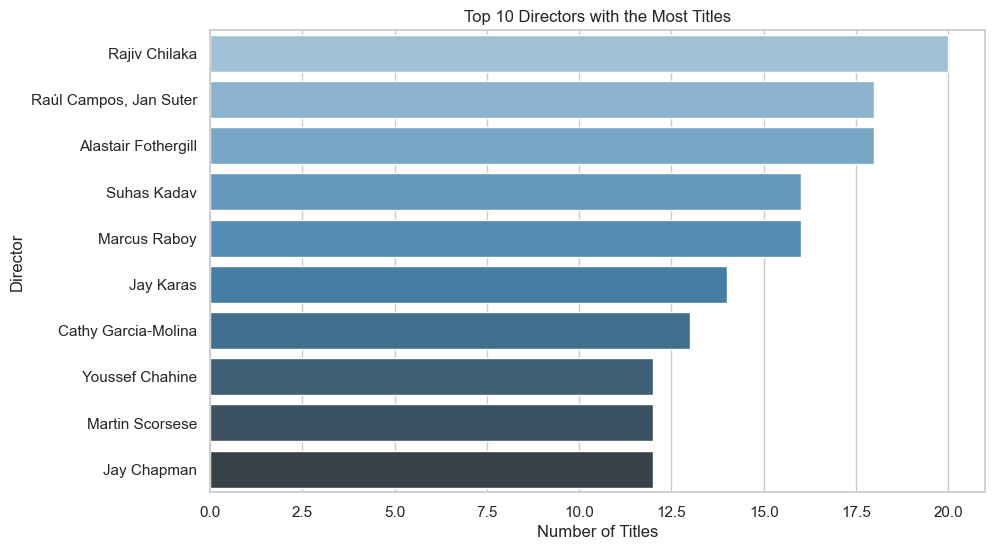

In [ ]:
if "director" in data.columns:
    series = data["director"].dropna()
    series = series[series.str.strip().str.lower() != "not given"]
    top_directors = series.value_counts().head(10)
    plt.figure(figsize=(10,6))
    sns.barplot(x=top_directors.values, y=top_directors.index, palette="Blues_d")
    plt.title("Top 10 Directors with the Most Titles")
    plt.xlabel("Number of Titles")
    plt.ylabel("Director")
    plt.show()

## Word Cloud of Movie Titles

Purpose:
- Visualize frequent words in movie titles to capture high-level themes.

How it executes:
- Filters rows where `type == 'Movie'`, concatenates titles, and renders a word cloud.
- The layout weights words by frequency; chart is displayed inline.

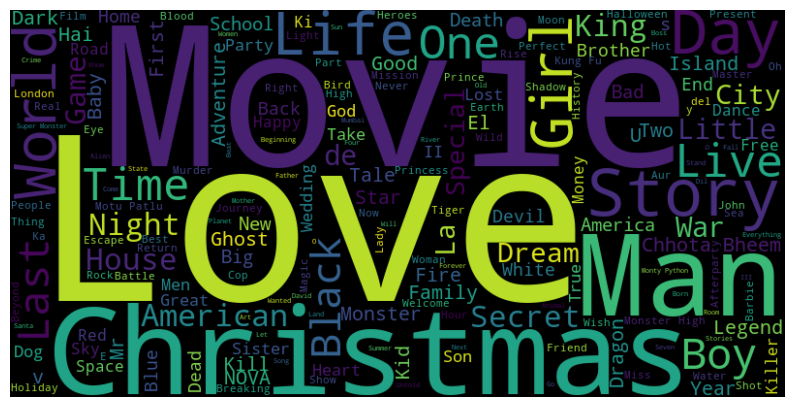

In [ ]:
if set(["type", "title"]).issubset(data.columns):
    titles = data[data["type"] == "Movie"]["title"].dropna()
    if not titles.empty:
        wc = WordCloud(width=800, height=400, background_color="black").generate(" ".join(titles))
        plt.figure(figsize=(10,6))
        plt.imshow(wc, interpolation="bilinear")
        plt.axis("off")
        plt.show()

### Conclusion and Key Insights

<div style="background:#F4F9FF;border-left:6px solid #2E86C1;padding:12px 16px;">
<b><span style="color:#2E86C1;">Snapshot</span></b><br/>
• <b>Total Titles:</b> 8,790<br/>
• <b>Composition:</b> <span style="color:#1F618D;">Movies 6,126</span> (≈69.7%), <span style="color:#1F618D;">TV Shows 2,664</span> (≈30.3%)<br/>
• <b>Release Range:</b> 1925–2021<br/>
• <b>Data Window:</b> 2008‑01‑01 to 2021‑09‑25; <b>Peak Year:</b> <mark>2019</mark> (2,016 additions)
</div>

---

<b><span style="color:#117A65;">Top Genres</span></b>

- International Movies: <mark>2,752</mark>
- Dramas: <mark>2,426</mark>
- Comedies: <mark>1,674</mark>
- International TV Shows: 1,349
- Documentaries: 869

---

<b><span style="color:#AF601A;">Most Prolific Directors</span></b> (excluding "Not Given")

- Rajiv Chilaka: <mark>20</mark>
- Raúl Campos & Jan Suter: <mark>18</mark>
- Alastair Fothergill: <mark>18</mark>
- Suhas Kadav: 16
- Marcus Raboy: 16

---

<b><span style="color:#7D3C98;">Key Takeaways</span></b>

- Catalog skews toward <span style="color:#7B241C;">movies</span> with strong <span style="color:#154360;">international</span> and <span style="color:#1B4F72;">drama</span> presence.
- <mark>2019</mark> marked the largest intake year; additions trend upward through the late 2010s.
- A small number of prolific directors contribute many titles; most directors appear infrequently.

<b><span style="color:#2E4053;">Next Steps</span></b>

- Engineer features: genre one‑hot/embeddings, director frequency, and recency.
- Build dashboards for year‑over‑year growth and genre mix.
- Use these features for recommendation or trend forecasting.